In [12]:
!pip install tensorflow
!pip install numpy

In [13]:
import tensorflow as tf
import numpy as np
import random

In [14]:
class TicTacToe:
    def __init__(self, board=None):
        if board is None:
            self.board = np.zeros((3, 3))  # Default to an empty board
        else:
            self.board = np.array(board)  # Initialize with a specific board state
        self.players = ['X', 'O']
        self.current_player = self.players[0]
        self.winner = None
        self.game_over = False

    def reset(self):
        self.board = np.zeros((3, 3))
        self.current_player = self.players[0]
        self.winner = None
        self.game_over = False

    def available_moves(self):
        moves = []
        for i in range(3):
            for j in range(3):
                if self.board[i][j] == 0:
                    moves.append((i, j))
        return moves

    def make_move(self, move):
        if self.board[move[0]][move[1]] != 0:
            return False
        self.board[move[0]][move[1]] = self.players.index(self.current_player) + 1
        self.check_winner()
        self.switch_player()
        return True

    def switch_player(self):
        if self.current_player == self.players[0]:
            self.current_player = self.players[1]
        else:
            self.current_player = self.players[0]

    def check_winner(self):
        # Check rows
        for i in range(3):
            if self.board[i][0] == self.board[i][1] == self.board[i][2] != 0:
                self.winner = self.players[int(self.board[i][0] - 1)]
                self.game_over = True
        # Check columns
        for j in range(3):
            if self.board[0][j] == self.board[1][j] == self.board[2][j] != 0:
                self.winner = self.players[int(self.board[0][j] - 1)]
                self.game_over = True
        # Check diagonals
        if self.board[0][0] == self.board[1][1] == self.board[2][2] != 0:
            self.winner = self.players[int(self.board[0][0] - 1)]
            self.game_over = True
        if self.board[0][2] == self.board[1][1] == self.board[2][0] != 0:
            self.winner = self.players[int(self.board[0][2] - 1)]
            self.game_over = True

    def print_board(self):
        print("-------------")
        for i in range(3):
            print("|", end=" ")
            for j in range(3):
                print(self.players[int(self.board[i][j] - 1)] if self.board[i][j] != 0 else " ", end=" | ")
            print()
            print("-------------")

In [15]:
game = TicTacToe()
game.current_player = game.players[0]
game.print_board()

while not game.game_over:
    move = input(f"{game.current_player}''s turn. Enter row and column (e.g. 0 0): ")
    move = tuple(map(int, move.split()))
    while move not in game.available_moves():
        move = input("Invalid move. Try again: ")
        move = tuple(map(int, move.split()))
    game.make_move(move)
    game.print_board()

if game.winner:
    print(f"{game.winner} wins!")
else:
    print("It's a tie!")

-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 0
-------------
| X |   |   | 
-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
O''s turn. Enter row and column (e.g. 0 0): 2 0
-------------
| X |   |   | 
-------------
|   |   |   | 
-------------
| O |   |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 1
-------------
| X | X |   | 
-------------
|   |   |   | 
-------------
| O |   |   | 
-------------
O''s turn. Enter row and column (e.g. 0 0): 2 1
-------------
| X | X |   | 
-------------
|   |   |   | 
-------------
| O | O |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 2
-------------
| X | X | X | 
-------------
|   |   |   | 
-------------
| O | O |   | 
-------------
X wins!


In [16]:
import random

class QLearningAgent:
    def __init__(self, alpha, epsilon, discount_factor):
        self.Q = {}  # The Q-table for storing Q-values
        self.alpha = alpha  # Learning rate
        self.epsilon = epsilon  # Exploration rate
        self.discount_factor = discount_factor  # Discount factor for future rewards

    def get_Q_value(self, state, action):
        state_tuple = tuple(map(tuple, state))  # Convert state to tuple for hashing
        if (state_tuple, action) not in self.Q:
            self.Q[(state_tuple, action)] = 0.0
        return self.Q[(state_tuple, action)]

    def choose_action(self, state, available_moves):
        """Epsilon-greedy policy to choose an action."""
        state_tuple = tuple(map(tuple, state))  # Convert state to tuple for hashing

        # Exploration: choose a random action with probability epsilon
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(available_moves)
        else:
            # Exploitation: choose the action with the maximum Q-value
            Q_values = [self.get_Q_value(state_tuple, action) for action in available_moves]
            max_Q = max(Q_values)
            best_actions = [action for i, action in enumerate(available_moves) if Q_values[i] == max_Q]
            return random.choice(best_actions)  # If multiple actions have the same Q-value, choose randomly

    def update_Q_value(self, state, action, reward, next_state):
        state_tuple = tuple(map(tuple, state))  # Convert the state to a tuple
        next_state_tuple = tuple(map(tuple, next_state))  # Convert the next state to a tuple

        # Check if the current state-action pair exists in Q-table, if not initialize it
        if (state_tuple, action) not in self.Q:
            self.Q[(state_tuple, action)] = 0.0

        # Get the Q-values for the next state
        game = TicTacToe(next_state_tuple)
        next_Q_values = [self.get_Q_value(next_state_tuple, next_action) for next_action in game.available_moves()]

        # Get the maximum Q-value for the next state
        max_next_Q = max(next_Q_values) if next_Q_values else 0.0

        # Update the Q-value for the current state-action pair using the Q-learning formula
        self.Q[(state_tuple, action)] += self.alpha * (reward + self.discount_factor * max_next_Q - self.Q[(state_tuple, action)])


In [17]:
def train(num_episodes, alpha, epsilon, discount_factor):
    agent = QLearningAgent(alpha, epsilon, discount_factor)

    for i in range(num_episodes):
        game = TicTacToe()  # Initialize a new game for each episode
        state = game.board

        while not game.game_over:  # Continue the game until it is over
            available_moves = game.available_moves()

            # If there are no available moves, the game must be over
            if not available_moves:
                break

            # Agent chooses an action
            action = agent.choose_action(state, available_moves)

            # Apply the action and update the game state
            game.make_move(action)
            next_state = game.board

            # Define reward structure
            if game.winner == game.players[0]:
                reward = 1  # Agent wins
            elif game.winner == game.players[1]:
                reward = -1  # Opponent wins
            else:
                reward = 0  # Game is ongoing or a tie

            # Update the Q-value
            agent.update_Q_value(state, action, reward, next_state)

            # Move to the next state
            state = next_state

    return agent


In [18]:
def test(agent, num_games):
    num_wins = 0
    for i in range(num_games):
        game = TicTacToe()  # Start a new game
        state = game.board  # Get the initial state of the board

        while not game.game_over:  # Use the boolean flag, not as a method call
            available_moves = game.available_moves()

            # If no available moves, break the loop (the game is a tie)
            if not available_moves:
                break

            if game.current_player == game.players[0]:  # Player 1 (agent)
                action = agent.choose_action(state, available_moves)
            else:  # Opponent (random)
                action = random.choice(available_moves)

            game.make_move(action)
            state = game.board  # Update state after move

        # Check if the agent won the game
        if game.winner == game.players[0]:
            num_wins += 1

    # Return the win percentage
    return num_wins / num_games * 100


In [19]:
# Train the Q-learning agent
agent = train(num_episodes=100000, alpha=0.5, epsilon=0.1, discount_factor=1.0)

# Test the Q-learning agent
win_percentage = test(agent, num_games=1000)
print("Win percentage: {:.2f}%".format(win_percentage))





Win percentage: 58.60%


In [20]:
pip install ipywidgets matplotlib


In [21]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output

class TicTacToeGUI:
    def __init__(self):
        self.game = TicTacToe()  # Initialize the TicTacToe game logic
        self.fig, self.ax = plt.subplots()  # Create a plot for the game board
        self.fig.canvas.toolbar_visible = False  # Hide toolbar for cleaner appearance
        self.fig.canvas.header_visible = False   # Hide header for cleaner appearance
        self.fig.canvas.footer_visible = False   # Hide footer for cleaner appearance
        self.fig.set_size_inches(4, 4)

        # Create a reset button
        self.reset_button = widgets.Button(description="Reset Game")
        self.reset_button.on_click(self.reset_game)

        # Display the widgets
        display(self.reset_button)
        self.draw_board()
        self.fig.canvas.mpl_connect("button_press_event", self.on_click)

    def draw_board(self):
        """Draws the Tic-Tac-Toe board and current state."""
        self.ax.clear()
        self.ax.set_xlim(0, 3)
        self.ax.set_ylim(0, 3)
        self.ax.set_xticks(np.arange(0, 4, 1))
        self.ax.set_yticks(np.arange(0, 4, 1))
        self.ax.grid(True)
        self.ax.set_aspect('equal')

        # Plot the current board state
        for i in range(3):
            for j in range(3):
                if self.game.board[i, j] == 1:
                    self.ax.text(j + 0.5, 2.5 - i, 'X', fontsize=24, va='center', ha='center')
                elif self.game.board[i, j] == 2:
                    self.ax.text(j + 0.5, 2.5 - i, 'O', fontsize=24, va='center', ha='center')

        plt.draw()

    def on_click(self, event):
        """Handles click events to make moves."""
        if self.game.game_over:
            return  # Ignore clicks if the game is over

        # Calculate the grid position clicked
        row = int(3 - event.ydata)  # Reverse the y-axis direction
        col = int(event.xdata)

        # Check if the click is within the valid area
        if row >= 0 and row < 3 and col >= 0 and col < 3:
            move = (row, col)
            if move in self.game.available_moves():
                self.game.current_player = self.game.players[0]  # Set current player as 'X'
                self.game.make_move(move)
                self.draw_board()

                if self.game.game_over:
                    print(f"Game Over! {self.game.winner} wins!" if self.game.winner else "It's a tie!")
                else:
                    # Random opponent move
                    opponent_move = np.random.choice(self.game.available_moves())
                    self.game.make_move(opponent_move)
                    self.draw_board()

                    if self.game.game_over:
                        print(f"Game Over! {self.game.winner} wins!" if self.game.winner else "It's a tie!")

    def reset_game(self, b=None):
        """Resets the game state and redraws the board."""
        self.game.reset()
        self.draw_board()

# Initialize the TicTacToe GUI
TicTacToeGUI()


<IPython.core.display.Javascript object>

Button(description='Reset Game', style=ButtonStyle())

In [ ]:
!pip install tensorflow
!pip install numpy

In [ ]:
import tensorflow as tf
import numpy as np
import random

In [ ]:
class TicTacToe:
    def __init__(self, board=None):
        if board is None:
            self.board = np.zeros((3, 3))  # Default to an empty board
        else:
            self.board = np.array(board)  # Initialize with a specific board state
        self.players = ['X', 'O']
        self.current_player = self.players[0]
        self.winner = None
        self.game_over = False

    def reset(self):
        self.board = np.zeros((3, 3))
        self.current_player = self.players[0]
        self.winner = None
        self.game_over = False

    def available_moves(self):
        moves = []
        for i in range(3):
            for j in range(3):
                if self.board[i][j] == 0:
                    moves.append((i, j))
        return moves

    def make_move(self, move):
        if self.board[move[0]][move[1]] != 0:
            return False
        self.board[move[0]][move[1]] = self.players.index(self.current_player) + 1
        self.check_winner()
        self.switch_player()
        return True

    def switch_player(self):
        if self.current_player == self.players[0]:
            self.current_player = self.players[1]
        else:
            self.current_player = self.players[0]

    def check_winner(self):
        # Check rows
        for i in range(3):
            if self.board[i][0] == self.board[i][1] == self.board[i][2] != 0:
                self.winner = self.players[int(self.board[i][0] - 1)]
                self.game_over = True
        # Check columns
        for j in range(3):
            if self.board[0][j] == self.board[1][j] == self.board[2][j] != 0:
                self.winner = self.players[int(self.board[0][j] - 1)]
                self.game_over = True
        # Check diagonals
        if self.board[0][0] == self.board[1][1] == self.board[2][2] != 0:
            self.winner = self.players[int(self.board[0][0] - 1)]
            self.game_over = True
        if self.board[0][2] == self.board[1][1] == self.board[2][0] != 0:
            self.winner = self.players[int(self.board[0][2] - 1)]
            self.game_over = True

    def print_board(self):
        print("-------------")
        for i in range(3):
            print("|", end=" ")
            for j in range(3):
                print(self.players[int(self.board[i][j] - 1)] if self.board[i][j] != 0 else " ", end=" | ")
            print()
            print("-------------")

In [ ]:
game = TicTacToe()
game.current_player = game.players[0]
game.print_board()

while not game.game_over:
    move = input(f"{game.current_player}''s turn. Enter row and column (e.g. 0 0): ")
    move = tuple(map(int, move.split()))
    while move not in game.available_moves():
        move = input("Invalid move. Try again: ")
        move = tuple(map(int, move.split()))
    game.make_move(move)
    game.print_board()

if game.winner:
    print(f"{game.winner} wins!")
else:
    print("It's a tie!")

-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 0
-------------
| X |   |   | 
-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
O''s turn. Enter row and column (e.g. 0 0): 2 0
-------------
| X |   |   | 
-------------
|   |   |   | 
-------------
| O |   |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 1
-------------
| X | X |   | 
-------------
|   |   |   | 
-------------
| O |   |   | 
-------------
O''s turn. Enter row and column (e.g. 0 0): 2 1
-------------
| X | X |   | 
-------------
|   |   |   | 
-------------
| O | O |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 2
-------------
| X | X | X | 
-------------
|   |   |   | 
-------------
| O | O |   | 
-------------
X wins!


In [ ]:
import random

class QLearningAgent:
    def __init__(self, alpha, epsilon, discount_factor):
        self.Q = {}  # The Q-table for storing Q-values
        self.alpha = alpha  # Learning rate
        self.epsilon = epsilon  # Exploration rate
        self.discount_factor = discount_factor  # Discount factor for future rewards

    def get_Q_value(self, state, action):
        state_tuple = tuple(map(tuple, state))  # Convert state to tuple for hashing
        if (state_tuple, action) not in self.Q:
            self.Q[(state_tuple, action)] = 0.0
        return self.Q[(state_tuple, action)]

    def choose_action(self, state, available_moves):
        """Epsilon-greedy policy to choose an action."""
        state_tuple = tuple(map(tuple, state))  # Convert state to tuple for hashing

        # Exploration: choose a random action with probability epsilon
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(available_moves)
        else:
            # Exploitation: choose the action with the maximum Q-value
            Q_values = [self.get_Q_value(state_tuple, action) for action in available_moves]
            max_Q = max(Q_values)
            best_actions = [action for i, action in enumerate(available_moves) if Q_values[i] == max_Q]
            return random.choice(best_actions)  # If multiple actions have the same Q-value, choose randomly

    def update_Q_value(self, state, action, reward, next_state):
        state_tuple = tuple(map(tuple, state))  # Convert the state to a tuple
        next_state_tuple = tuple(map(tuple, next_state))  # Convert the next state to a tuple

        # Check if the current state-action pair exists in Q-table, if not initialize it
        if (state_tuple, action) not in self.Q:
            self.Q[(state_tuple, action)] = 0.0

        # Get the Q-values for the next state
        game = TicTacToe(next_state_tuple)
        next_Q_values = [self.get_Q_value(next_state_tuple, next_action) for next_action in game.available_moves()]

        # Get the maximum Q-value for the next state
        max_next_Q = max(next_Q_values) if next_Q_values else 0.0

        # Update the Q-value for the current state-action pair using the Q-learning formula
        self.Q[(state_tuple, action)] += self.alpha * (reward + self.discount_factor * max_next_Q - self.Q[(state_tuple, action)])


In [ ]:
def train(num_episodes, alpha, epsilon, discount_factor):
    agent = QLearningAgent(alpha, epsilon, discount_factor)

    for i in range(num_episodes):
        game = TicTacToe()  # Initialize a new game for each episode
        state = game.board

        while not game.game_over:  # Continue the game until it is over
            available_moves = game.available_moves()

            # If there are no available moves, the game must be over
            if not available_moves:
                break

            # Agent chooses an action
            action = agent.choose_action(state, available_moves)

            # Apply the action and update the game state
            game.make_move(action)
            next_state = game.board

            # Define reward structure
            if game.winner == game.players[0]:
                reward = 1  # Agent wins
            elif game.winner == game.players[1]:
                reward = -1  # Opponent wins
            else:
                reward = 0  # Game is ongoing or a tie

            # Update the Q-value
            agent.update_Q_value(state, action, reward, next_state)

            # Move to the next state
            state = next_state

    return agent


In [ ]:
def test(agent, num_games):
    num_wins = 0
    for i in range(num_games):
        game = TicTacToe()  # Start a new game
        state = game.board  # Get the initial state of the board

        while not game.game_over:  # Use the boolean flag, not as a method call
            available_moves = game.available_moves()

            # If no available moves, break the loop (the game is a tie)
            if not available_moves:
                break

            if game.current_player == game.players[0]:  # Player 1 (agent)
                action = agent.choose_action(state, available_moves)
            else:  # Opponent (random)
                action = random.choice(available_moves)

            game.make_move(action)
            state = game.board  # Update state after move

        # Check if the agent won the game
        if game.winner == game.players[0]:
            num_wins += 1

    # Return the win percentage
    return num_wins / num_games * 100


In [ ]:
# Train the Q-learning agent
agent = train(num_episodes=100000, alpha=0.5, epsilon=0.1, discount_factor=1.0)

# Test the Q-learning agent
win_percentage = test(agent, num_games=1000)
print("Win percentage: {:.2f}%".format(win_percentage))





Win percentage: 58.60%


In [ ]:
pip install ipywidgets matplotlib


In [ ]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output

class TicTacToeGUI:
    def __init__(self):
        self.game = TicTacToe()  # Initialize the TicTacToe game logic
        self.fig, self.ax = plt.subplots()  # Create a plot for the game board
        self.fig.canvas.toolbar_visible = False  # Hide toolbar for cleaner appearance
        self.fig.canvas.header_visible = False   # Hide header for cleaner appearance
        self.fig.canvas.footer_visible = False   # Hide footer for cleaner appearance
        self.fig.set_size_inches(4, 4)

        # Create a reset button
        self.reset_button = widgets.Button(description="Reset Game")
        self.reset_button.on_click(self.reset_game)

        # Display the widgets
        display(self.reset_button)
        self.draw_board()
        self.fig.canvas.mpl_connect("button_press_event", self.on_click)

    def draw_board(self):
        """Draws the Tic-Tac-Toe board and current state."""
        self.ax.clear()
        self.ax.set_xlim(0, 3)
        self.ax.set_ylim(0, 3)
        self.ax.set_xticks(np.arange(0, 4, 1))
        self.ax.set_yticks(np.arange(0, 4, 1))
        self.ax.grid(True)
        self.ax.set_aspect('equal')

        # Plot the current board state
        for i in range(3):
            for j in range(3):
                if self.game.board[i, j] == 1:
                    self.ax.text(j + 0.5, 2.5 - i, 'X', fontsize=24, va='center', ha='center')
                elif self.game.board[i, j] == 2:
                    self.ax.text(j + 0.5, 2.5 - i, 'O', fontsize=24, va='center', ha='center')

        plt.draw()

    def on_click(self, event):
        """Handles click events to make moves."""
        if self.game.game_over:
            return  # Ignore clicks if the game is over

        # Calculate the grid position clicked
        row = int(3 - event.ydata)  # Reverse the y-axis direction
        col = int(event.xdata)

        # Check if the click is within the valid area
        if row >= 0 and row < 3 and col >= 0 and col < 3:
            move = (row, col)
            if move in self.game.available_moves():
                self.game.current_player = self.game.players[0]  # Set current player as 'X'
                self.game.make_move(move)
                self.draw_board()

                if self.game.game_over:
                    print(f"Game Over! {self.game.winner} wins!" if self.game.winner else "It's a tie!")
                else:
                    # Random opponent move
                    opponent_move = np.random.choice(self.game.available_moves())
                    self.game.make_move(opponent_move)
                    self.draw_board()

                    if self.game.game_over:
                        print(f"Game Over! {self.game.winner} wins!" if self.game.winner else "It's a tie!")

    def reset_game(self, b=None):
        """Resets the game state and redraws the board."""
        self.game.reset()
        self.draw_board()

# Initialize the TicTacToe GUI
TicTacToeGUI()


<IPython.core.display.Javascript object>

Button(description='Reset Game', style=ButtonStyle())

In [ ]:
!pip install tensorflow
!pip install numpy

In [ ]:
import tensorflow as tf
import numpy as np
import random

In [ ]:
class TicTacToe:
    def __init__(self, board=None):
        if board is None:
            self.board = np.zeros((3, 3))  # Default to an empty board
        else:
            self.board = np.array(board)  # Initialize with a specific board state
        self.players = ['X', 'O']
        self.current_player = self.players[0]
        self.winner = None
        self.game_over = False

    def reset(self):
        self.board = np.zeros((3, 3))
        self.current_player = self.players[0]
        self.winner = None
        self.game_over = False

    def available_moves(self):
        moves = []
        for i in range(3):
            for j in range(3):
                if self.board[i][j] == 0:
                    moves.append((i, j))
        return moves

    def make_move(self, move):
        if self.board[move[0]][move[1]] != 0:
            return False
        self.board[move[0]][move[1]] = self.players.index(self.current_player) + 1
        self.check_winner()
        self.switch_player()
        return True

    def switch_player(self):
        if self.current_player == self.players[0]:
            self.current_player = self.players[1]
        else:
            self.current_player = self.players[0]

    def check_winner(self):
        # Check rows
        for i in range(3):
            if self.board[i][0] == self.board[i][1] == self.board[i][2] != 0:
                self.winner = self.players[int(self.board[i][0] - 1)]
                self.game_over = True
        # Check columns
        for j in range(3):
            if self.board[0][j] == self.board[1][j] == self.board[2][j] != 0:
                self.winner = self.players[int(self.board[0][j] - 1)]
                self.game_over = True
        # Check diagonals
        if self.board[0][0] == self.board[1][1] == self.board[2][2] != 0:
            self.winner = self.players[int(self.board[0][0] - 1)]
            self.game_over = True
        if self.board[0][2] == self.board[1][1] == self.board[2][0] != 0:
            self.winner = self.players[int(self.board[0][2] - 1)]
            self.game_over = True

    def print_board(self):
        print("-------------")
        for i in range(3):
            print("|", end=" ")
            for j in range(3):
                print(self.players[int(self.board[i][j] - 1)] if self.board[i][j] != 0 else " ", end=" | ")
            print()
            print("-------------")

In [ ]:
game = TicTacToe()
game.current_player = game.players[0]
game.print_board()

while not game.game_over:
    move = input(f"{game.current_player}''s turn. Enter row and column (e.g. 0 0): ")
    move = tuple(map(int, move.split()))
    while move not in game.available_moves():
        move = input("Invalid move. Try again: ")
        move = tuple(map(int, move.split()))
    game.make_move(move)
    game.print_board()

if game.winner:
    print(f"{game.winner} wins!")
else:
    print("It's a tie!")

-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 0
-------------
| X |   |   | 
-------------
|   |   |   | 
-------------
|   |   |   | 
-------------
O''s turn. Enter row and column (e.g. 0 0): 2 0
-------------
| X |   |   | 
-------------
|   |   |   | 
-------------
| O |   |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 1
-------------
| X | X |   | 
-------------
|   |   |   | 
-------------
| O |   |   | 
-------------
O''s turn. Enter row and column (e.g. 0 0): 2 1
-------------
| X | X |   | 
-------------
|   |   |   | 
-------------
| O | O |   | 
-------------
X''s turn. Enter row and column (e.g. 0 0): 0 2
-------------
| X | X | X | 
-------------
|   |   |   | 
-------------
| O | O |   | 
-------------
X wins!


In [ ]:
import random

class QLearningAgent:
    def __init__(self, alpha, epsilon, discount_factor):
        self.Q = {}  # The Q-table for storing Q-values
        self.alpha = alpha  # Learning rate
        self.epsilon = epsilon  # Exploration rate
        self.discount_factor = discount_factor  # Discount factor for future rewards

    def get_Q_value(self, state, action):
        state_tuple = tuple(map(tuple, state))  # Convert state to tuple for hashing
        if (state_tuple, action) not in self.Q:
            self.Q[(state_tuple, action)] = 0.0
        return self.Q[(state_tuple, action)]

    def choose_action(self, state, available_moves):
        """Epsilon-greedy policy to choose an action."""
        state_tuple = tuple(map(tuple, state))  # Convert state to tuple for hashing

        # Exploration: choose a random action with probability epsilon
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(available_moves)
        else:
            # Exploitation: choose the action with the maximum Q-value
            Q_values = [self.get_Q_value(state_tuple, action) for action in available_moves]
            max_Q = max(Q_values)
            best_actions = [action for i, action in enumerate(available_moves) if Q_values[i] == max_Q]
            return random.choice(best_actions)  # If multiple actions have the same Q-value, choose randomly

    def update_Q_value(self, state, action, reward, next_state):
        state_tuple = tuple(map(tuple, state))  # Convert the state to a tuple
        next_state_tuple = tuple(map(tuple, next_state))  # Convert the next state to a tuple

        # Check if the current state-action pair exists in Q-table, if not initialize it
        if (state_tuple, action) not in self.Q:
            self.Q[(state_tuple, action)] = 0.0

        # Get the Q-values for the next state
        game = TicTacToe(next_state_tuple)
        next_Q_values = [self.get_Q_value(next_state_tuple, next_action) for next_action in game.available_moves()]

        # Get the maximum Q-value for the next state
        max_next_Q = max(next_Q_values) if next_Q_values else 0.0

        # Update the Q-value for the current state-action pair using the Q-learning formula
        self.Q[(state_tuple, action)] += self.alpha * (reward + self.discount_factor * max_next_Q - self.Q[(state_tuple, action)])


In [ ]:
def train(num_episodes, alpha, epsilon, discount_factor):
    agent = QLearningAgent(alpha, epsilon, discount_factor)

    for i in range(num_episodes):
        game = TicTacToe()  # Initialize a new game for each episode
        state = game.board

        while not game.game_over:  # Continue the game until it is over
            available_moves = game.available_moves()

            # If there are no available moves, the game must be over
            if not available_moves:
                break

            # Agent chooses an action
            action = agent.choose_action(state, available_moves)

            # Apply the action and update the game state
            game.make_move(action)
            next_state = game.board

            # Define reward structure
            if game.winner == game.players[0]:
                reward = 1  # Agent wins
            elif game.winner == game.players[1]:
                reward = -1  # Opponent wins
            else:
                reward = 0  # Game is ongoing or a tie

            # Update the Q-value
            agent.update_Q_value(state, action, reward, next_state)

            # Move to the next state
            state = next_state

    return agent


In [ ]:
def test(agent, num_games):
    num_wins = 0
    for i in range(num_games):
        game = TicTacToe()  # Start a new game
        state = game.board  # Get the initial state of the board

        while not game.game_over:  # Use the boolean flag, not as a method call
            available_moves = game.available_moves()

            # If no available moves, break the loop (the game is a tie)
            if not available_moves:
                break

            if game.current_player == game.players[0]:  # Player 1 (agent)
                action = agent.choose_action(state, available_moves)
            else:  # Opponent (random)
                action = random.choice(available_moves)

            game.make_move(action)
            state = game.board  # Update state after move

        # Check if the agent won the game
        if game.winner == game.players[0]:
            num_wins += 1

    # Return the win percentage
    return num_wins / num_games * 100


In [ ]:
# Train the Q-learning agent
agent = train(num_episodes=100000, alpha=0.5, epsilon=0.1, discount_factor=1.0)

# Test the Q-learning agent
win_percentage = test(agent, num_games=1000)
print("Win percentage: {:.2f}%".format(win_percentage))





Win percentage: 58.60%


In [ ]:
pip install ipywidgets matplotlib


Button(description='Reset Game', style=ButtonStyle())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

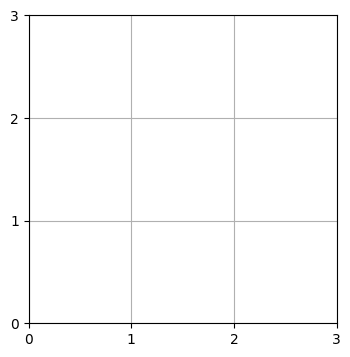

In [22]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import ipywidgets as widgets
from IPython.display import display, clear_output

class TicTacToeGUI:
    def __init__(self):
        self.game = TicTacToe()  # Initialize the TicTacToe game logic
        self.fig, self.ax = plt.subplots()  # Create a plot for the game board
        self.fig.canvas.toolbar_visible = False  # Hide toolbar for cleaner appearance
        self.fig.canvas.header_visible = False   # Hide header for cleaner appearance
        self.fig.canvas.footer_visible = False   # Hide footer for cleaner appearance
        self.fig.set_size_inches(4, 4)

        # Create a reset button
        self.reset_button = widgets.Button(description="Reset Game")
        self.reset_button.on_click(self.reset_game)

        # Display the widgets
        display(self.reset_button)
        self.draw_board()
        self.fig.canvas.mpl_connect("button_press_event", self.on_click)

    def draw_board(self):
        """Draws the Tic-Tac-Toe board and current state."""
        self.ax.clear()
        self.ax.set_xlim(0, 3)
        self.ax.set_ylim(0, 3)
        self.ax.set_xticks(np.arange(0, 4, 1))
        self.ax.set_yticks(np.arange(0, 4, 1))
        self.ax.grid(True)
        self.ax.set_aspect('equal')

        # Plot the current board state
        for i in range(3):
            for j in range(3):
                if self.game.board[i, j] == 1:
                    self.ax.text(j + 0.5, 2.5 - i, 'X', fontsize=24, va='center', ha='center')
                elif self.game.board[i, j] == 2:
                    self.ax.text(j + 0.5, 2.5 - i, 'O', fontsize=24, va='center', ha='center')

        plt.draw()

    def on_click(self, event):
        """Handles click events to make moves."""
        if self.game.game_over:
            return  # Ignore clicks if the game is over

        # Calculate the grid position clicked
        row = int(3 - event.ydata)  # Reverse the y-axis direction
        col = int(event.xdata)

        # Check if the click is within the valid area
        if row >= 0 and row < 3 and col >= 0 and col < 3:
            move = (row, col)
            if move in self.game.available_moves():
                self.game.current_player = self.game.players[0]  # Set current player as 'X'
                self.game.make_move(move)
                self.draw_board()

                if self.game.game_over:
                    print(f"Game Over! {self.game.winner} wins!" if self.game.winner else "It's a tie!")
                else:
                    # Random opponent move
                    opponent_move = np.random.choice(self.game.available_moves())
                    self.game.make_move(opponent_move)
                    self.draw_board()

                    if self.game.game_over:
                        print(f"Game Over! {self.game.winner} wins!" if self.game.winner else "It's a tie!")

    def reset_game(self, b=None):
        """Resets the game state and redraws the board."""
        self.game.reset()
        self.draw_board()

# Initialize the TicTacToe GUI
TicTacToeGUI()
